# Direct Causal Cascade in the Stock Market  
### Reproducing Figures from Arnéodo, Muzy & Sornette (1998)

This notebook aims to reproduce, as closely as possible, the structure of Figures 1–3:

- **Figure 1:** log-price, centered log-volatility walk, shuffled version, and their autocorrelations.  
- **Figure 2:** log-volatility correlation vs log-lag for several scales.  
- **Figure 3:** mutual information cone across time and scale, for original and shuffled data.

Assumptions:
- Input data: CSV with columns `datetime, price` sampled at fixed interval (e.g. 5 minutes).
- We use a discrete wavelet transform with Haar wavelet to approximate the construction in the paper.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8')
%matplotlib inline

from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]


## 1. Load and preprocess data

We:
- Load intraday prices
- Compute log-prices
- Remove intraday seasonality from 1-step returns
- Reconstruct a deseasonalized log-price series (used for all subsequent analysis)


In [2]:


DATA_PATH = "SandP_log2min.dat"   # one value per row

# Try reading with header; if no header, fallback
try:
    df = pd.read_csv(DATA_PATH)
    if df.shape[1] == 1:
        df.columns = ['price']
except:
    df = pd.read_csv(DATA_PATH, header=None)
    df.columns = ['price']

df = df.dropna().reset_index(drop=True)

# Log-price
df['log_price'] = np.log(df['price'])

# Since there is no intraday pattern, we skip deseasonalization
df['log_price_deseason'] = df['log_price']

df.head()



,price,log_price,log_price_deseason
0,9.710267,2.273184,2.273184
1,9.710085,2.273165,2.273165
2,9.709599,2.273115,2.273115
3,9.709478,2.273103,2.273103
4,9.709296,2.273084,2.273084


## 2. Wavelet transform and centered log-volatility walk

We:
- Apply a discrete wavelet transform (Haar) to the deseasonalized log-price.
- Use detail coefficients to define scale-dependent fluctuations.
- Build local volatility and log-volatility at each scale.
- Construct the centered log-volatility walk at a chosen scale (~20 minutes).


In [3]:

# =========================================================
# 1. Wavelet definitions (analytical, continuous)
# =========================================================

def smooth_step(u, u0, eps):
    return 0.5 * (1 + np.tanh((u - u0) / eps))

def psi_haar_smooth(u, eps=0.02):
    return (smooth_step(u, -0.5, eps)
            - 2 * smooth_step(u, 0.0, eps)
            + smooth_step(u, 0.5, eps))

def psi_mexh(u):
    return (1 - u**2) * np.exp(-0.5 * u**2)

def psi_gauss1(u):
    return -u * np.exp(-0.5 * u**2)

def psi_gauss2(u):
    return (u**2 - 1) * np.exp(-0.5 * u**2)

# =========================================================
# 2. Scale wavelet to arbitrary scale a
# =========================================================

def scale_wavelet(psi, a, dt):
    L = int(10 * a / dt)
    if L < 2:
        L = 2
    u = np.linspace(-L/2, L/2, L) / a
    psi_scaled = psi(u) / a
    return u * a, psi_scaled

# =========================================================
# 3. General FFT-based CWT
# =========================================================

def cwt_fft(f, dt, scales, psi):
    W = []
    for a in scales:
        _, psi_a = scale_wavelet(psi, a, dt)
        conv = fftconvolve(f, psi_a[::-1], mode='same') * dt
        W.append(conv)
    return np.array(W)


max_level = 10

log_price = np.array(df['log_price_deseason'].values)
dt = 1.0  # or whatever your sampling interval is

# Replace DWT scales with CWT scales
scales = np.linspace(2,10024,150)
print("scales:", scales)

# Compute Haar CWT (full-length coefficients)
detail_series = cwt_fft(log_price, dt, scales, psi_haar_smooth)

print("\nHaar CWT detail series shape:", detail_series.shape)
print("(n_scales, n_time) =", detail_series.shape)



scales: [2.00000000e+00 6.92617450e+01 1.36523490e+02 2.03785235e+02
 2.71046980e+02 3.38308725e+02 4.05570470e+02 4.72832215e+02
 5.40093960e+02 6.07355705e+02 6.74617450e+02 7.41879195e+02
 8.09140940e+02 8.76402685e+02 9.43664430e+02 1.01092617e+03
 1.07818792e+03 1.14544966e+03 1.21271141e+03 1.27997315e+03
 1.34723490e+03 1.41449664e+03 1.48175839e+03 1.54902013e+03
 1.61628188e+03 1.68354362e+03 1.75080537e+03 1.81806711e+03
 1.88532886e+03 1.95259060e+03 2.01985235e+03 2.08711409e+03
 2.15437584e+03 2.22163758e+03 2.28889933e+03 2.35616107e+03
 2.42342282e+03 2.49068456e+03 2.55794631e+03 2.62520805e+03
 2.69246980e+03 2.75973154e+03 2.82699329e+03 2.89425503e+03
 2.96151678e+03 3.02877852e+03 3.09604027e+03 3.16330201e+03
 3.23056376e+03 3.29782550e+03 3.36508725e+03 3.43234899e+03
 3.49961074e+03 3.56687248e+03 3.63413423e+03 3.70139597e+03
 3.76865772e+03 3.83591946e+03 3.90318121e+03 3.97044295e+03
 4.03770470e+03 4.10496644e+03 4.17222819e+03 4.23948993e+03
 4.30675168e+03 

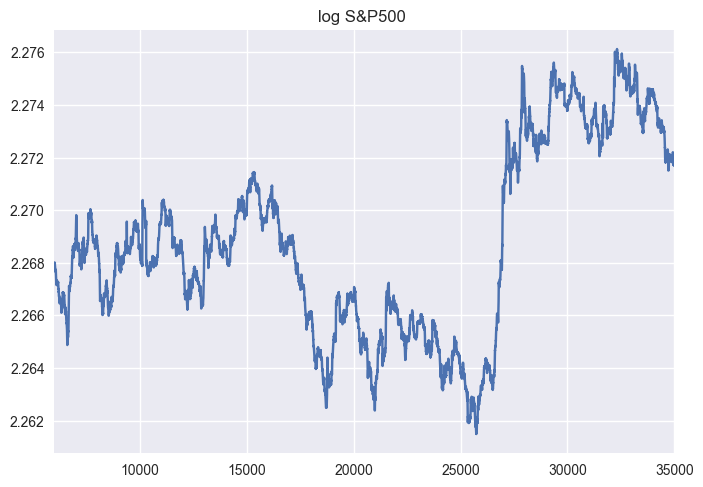

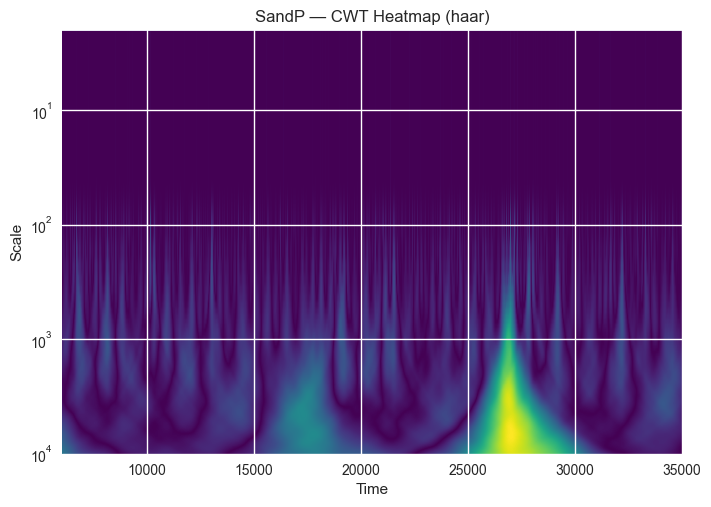

In [4]:
# for row in detail_series[:20]:
#     plt.plot(row[100:-100])
# plt.show()
clipping_start=6024
clipping_end=35000
t = np.arange(clipping_start, clipping_end)
plt.plot(t,log_price[clipping_start:clipping_end])
plt.title("log S&P500 ")
ax = plt.gca()
ax.set_xbound([clipping_start, clipping_end])
plt.show()
plt.imshow(np.abs(detail_series[:,clipping_start:clipping_end]),
        extent=[clipping_start, clipping_end, scales[-1], scales[0]],
        aspect='auto', cmap='viridis')
plt.title(f"SandP — CWT Heatmap (haar)")
plt.xlabel("Time")
plt.ylabel("Scale")
plt.yscale('log')

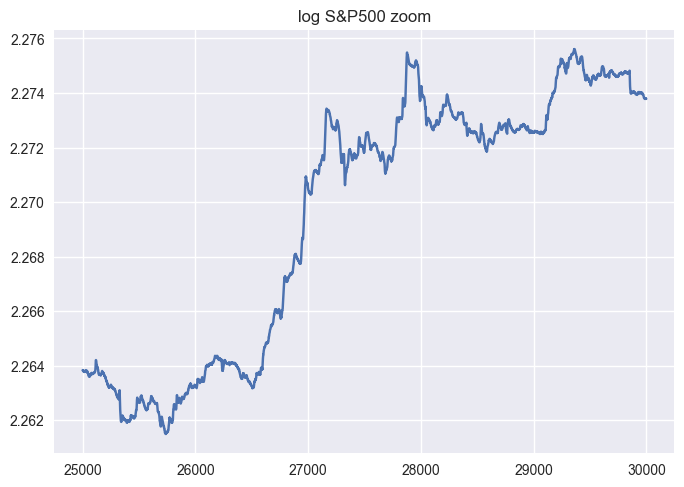

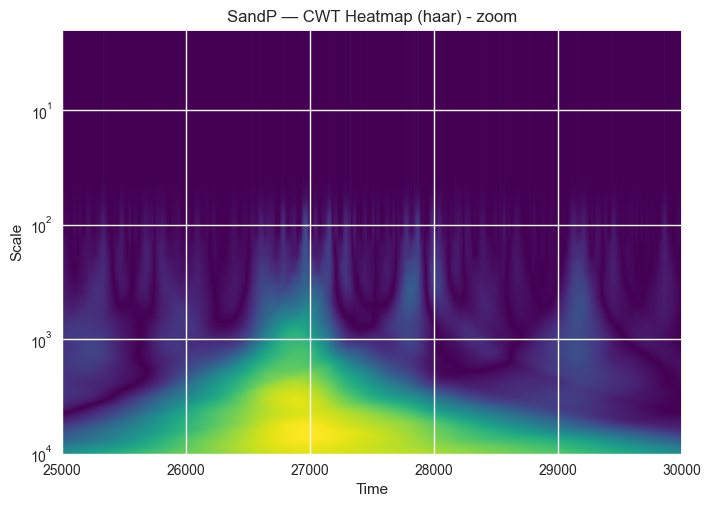

In [5]:
clipping_start=25000
clipping_end=30000
t = np.arange(clipping_start, clipping_end)
plt.plot(t,log_price[clipping_start:clipping_end])
plt.title("log S&P500 zoom")
plt.show()

plt.imshow(np.abs(detail_series[:,clipping_start:clipping_end]),
        extent=[clipping_start, clipping_end, scales[-1], scales[0]],
        aspect='auto', cmap='viridis')
plt.title(f"SandP — CWT Heatmap (haar) - zoom")
plt.xlabel("Time")
plt.ylabel("Scale")
plt.yscale('log')

## 3. Local volatility estimation

In [6]:
window = 50  # window for local volatility

vol_series = []
for s_idx in range(len(scales)):
    d = detail_series[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series.append(vol)

vol_series = np.array(vol_series)
log_vol_series = np.log(vol_series + 1e-12)

# Choose a scale index for ~20 min (adjust if your base step != 5 min)
scale_idx_20m = 5  # e.g. 2 * base step
w_a = log_vol_series[scale_idx_20m]
w_a_centered = w_a - np.mean(w_a)
v_a = np.cumsum(w_a_centered)

len(v_a)


640533

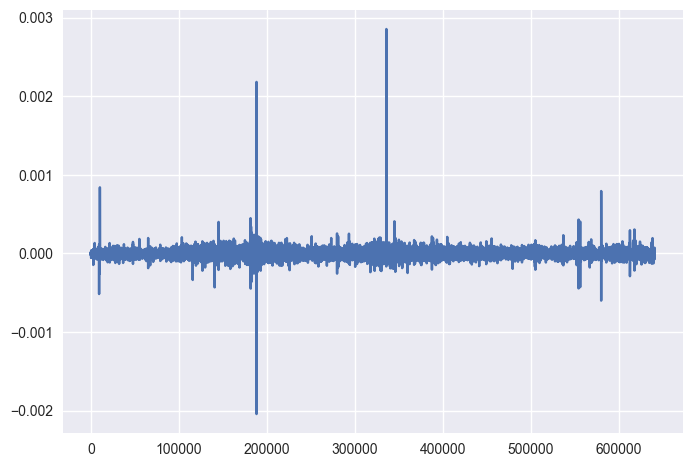

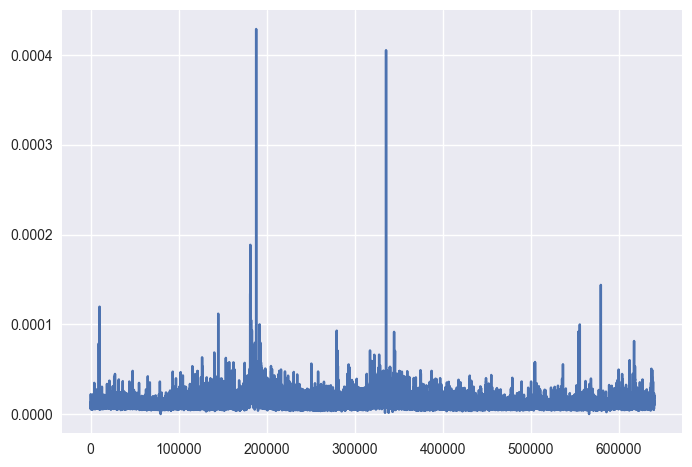

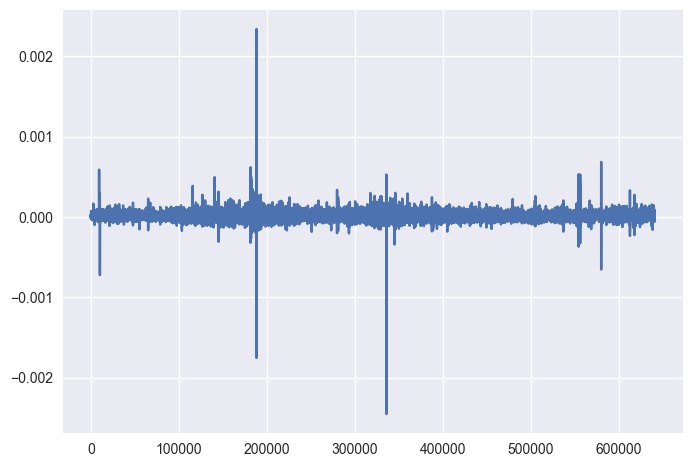

In [7]:
ind = 0

plt.plot(detail_series[ind][100:])
plt.show()
plt.plot(vol_series[ind][100:])
plt.show()
plt.plot(vol_series[ind][100:]-detail_series[ind][100:])
plt.show()

## 3. Figure 1: log-price, centered log-volatility walk, shuffled version

We now build the three time series:
- (a) log-price
- (b) centered log-volatility walk
- (c) same after shuffling the increments of log-price (as in the paper).


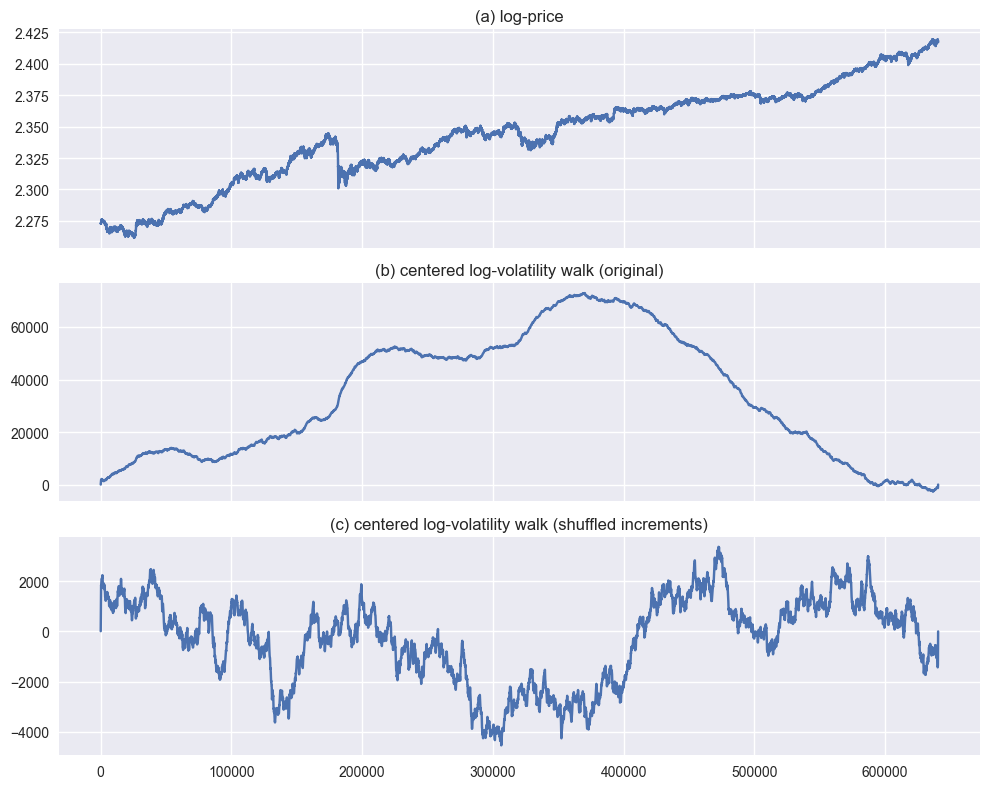

In [8]:
# (a) log-price
t = np.arange(len(df))
logP = df['log_price_deseason'].values

# (c) shuffled increments version
increments = np.diff(logP)
shuffled_increments = np.random.permutation(increments)
logP_shuffled = np.concatenate([[logP[0]], logP[0] + np.cumsum(shuffled_increments)])

# Recompute wavelet-based log-volatility walk for shuffled series
detail_series_sh = cwt_fft(logP_shuffled, dt, scales,psi_haar_smooth)


vol_series_sh = []
for s_idx in range(len(scales)):
    d = detail_series_sh[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh.append(vol)
vol_series_sh = np.array(vol_series_sh)
log_vol_series_sh = np.log(vol_series_sh + 1e-12)

w_a_sh = log_vol_series_sh[scale_idx_20m]
w_a_sh_centered = w_a_sh - np.mean(w_a_sh)
v_a_sh = np.cumsum(w_a_sh_centered)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, logP)
axes[0].set_title('(a) log-price')

axes[1].plot(t, v_a)
axes[1].set_title('(b) centered log-volatility walk (original)')

axes[2].plot(t, v_a_sh)
axes[2].set_title('(c) centered log-volatility walk (shuffled increments)')

plt.tight_layout()
plt.show()


## 4. Autocorrelation of returns vs log-volatility

### Figure 1′: Autocorrelations (returns and log-volatility)

We compute:
- (a′) autocorrelation of 1-step returns
- (b′) autocorrelation of log-volatility at scale ~20 min
- (c′) same for shuffled series


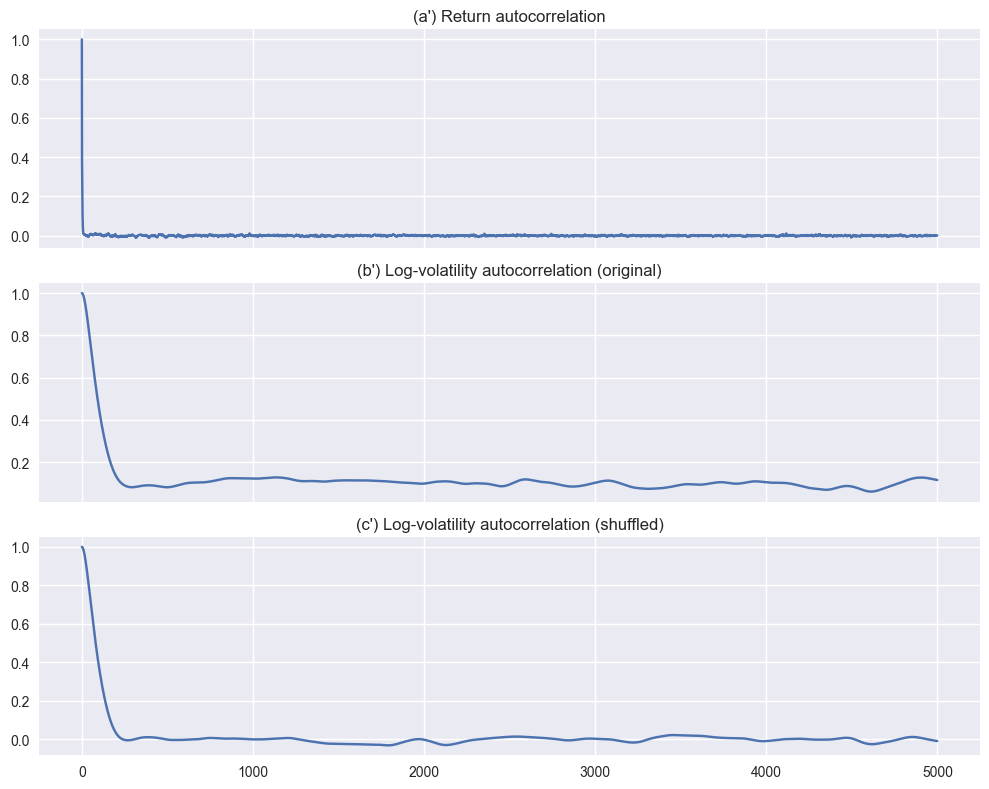

In [9]:
from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]

def corr_function(x, max_lag):
    """
    Normalized autocorrelation function C(Δt) for a 1D series x,
    for lags 0..max_lag.
    """
    x = np.asarray(x, float)
    n = len(x)

    # raw autocovariance via FFT convolution
    c = covariance_fft(x)

    # unbiased normalization by number of overlapping points
    norm = np.arange(n, 0, -1)
    c = c / norm

    # normalize to get correlation function: C(0) = 1
    c = c / c[0]

    return c[:max_lag + 1]

max_lag = 5000

# (a′) return autocorrelation
ret = np.diff(df['log_price_deseason'].values)
ret_ac = covariance_fft(ret)

# (b′) log-volatility autocorrelation (original)
w = w_a
w_ac = covariance_fft(w)

# (c′) log-volatility autocorrelation (shuffled)
w_sh = w_a_sh
w_sh_ac = covariance_fft(w_sh)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(ret_ac[:max_lag])
axes[0].set_title("(a') Return autocorrelation")

axes[1].plot(w_ac[:max_lag])
axes[1].set_title("(b') Log-volatility autocorrelation (original)")

axes[2].plot(w_sh_ac[:max_lag])
axes[2].set_title("(c') Log-volatility autocorrelation (shuffled)")

plt.tight_layout()
plt.show()


## 4. Figure 2: Log-volatility correlation vs log-lag for several scales(TODO - wrong figure)

We:
- Choose several scales (e.g. small, medium, large)
- Compute autocorrelation of log-volatility at each scale
- Plot correlation vs \\(\\ln \\Delta t\\) and show the collapse.


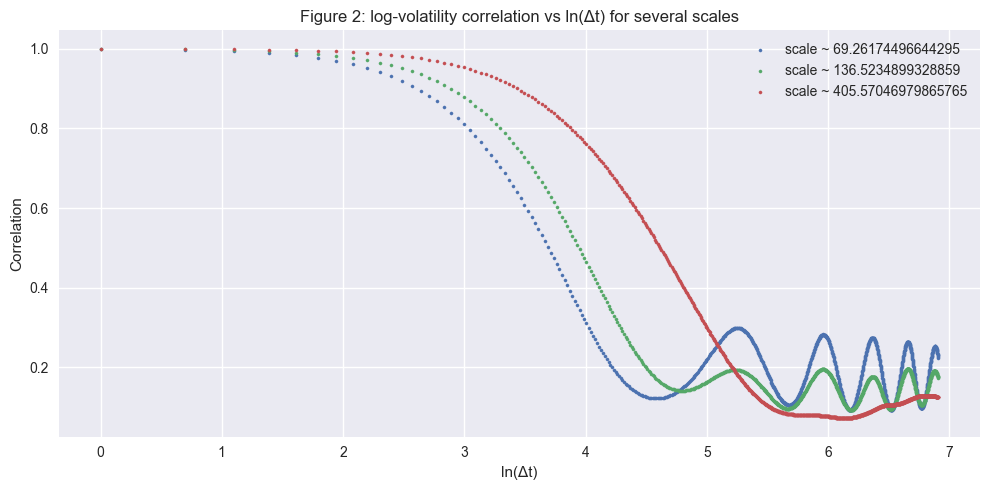

In [10]:
# Choose a few scale indices (adjust depending on your sampling)
scale_indices = [1, 2, 6]  # example: smaller, medium, larger scales
labels = [f'scale ~ {scales[i]}' for i in scale_indices]

max_lag_fig2 = 1000
lags = np.arange(1, max_lag_fig2+1)

plt.figure(figsize=(10, 5))
for idx, lab in zip(scale_indices, labels):
    w_s = log_vol_series[idx]          # this is ω_a(t)
    C = corr_function(w_s,max_lag_fig2)
    # skip lag 0, plot Δt = 1..max_lag
    plt.scatter(np.log(lags), C[1:], s=5, label=lab)

plt.xlabel('ln(Δt)')
plt.ylabel('Correlation')
plt.title('Figure 2: log-volatility correlation vs ln(Δt) for several scales')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Figure 3: Mutual information cone across time and scale (TODO - doesn't seem to show what was shown in the paper)

We compute the mutual information between log-volatility at different scales and times, using the Gaussian approximation:

\

\[
I = -\\frac{1}{2} \\log(1 - \\rho^2),
\\]



where \\(\\rho\\) is the Pearson correlation.


In [34]:
extend_computation = True

In [35]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import multiprocess as mp
from IPython.display import clear_output

# -----------------------------
# 1. Precompute centered series
# -----------------------------
max_time_lag = 200
ref_idx = 0  # smallest scale as reference
max_scale_idx=16
w_a_centered_list = [log_vol - np.mean(log_vol) for log_vol in log_vol_series]
w_ref = w_a_centered_list[ref_idx]

I_map = np.zeros((len(scales), 2*max_time_lag+1))


# -----------------------------
# 2. Worker function
# -----------------------------
def compute_I(args):
    """
    args = (s_idx, dt, w_a_centered_list, w_ref)
    Everything is passed explicitly so workers don't rely on notebook globals.
    """
    import numpy as np
    from sklearn.feature_selection import mutual_info_regression

    s_idx, dt, w_list, w_ref_local = args

    w_other = w_list[s_idx]

    # Align time series depending on lag
    if dt >= 0:
        x = w_other[:-dt or None]
        y = w_ref_local[dt:]
    else:
        x = w_other[-dt:]
        y = w_ref_local[:dt or None]

    # Too short → skip
    if len(x) < 10:
        return 0.0

    # Compute MI
    I = mutual_info_regression(x.reshape(-1,1), y, n_jobs=1)
    return float(I[0])
if not extend_computation:
# -----------------------------
# 3. Build task list
# -----------------------------
    tasks = [
        (s_idx, dt, w_a_centered_list, w_ref)
        for s_idx in range(max_scale_idx)
        for dt in range(-max_time_lag, max_time_lag+1)
    ]
    print(len(tasks))

    extent = [-max_time_lag, max_time_lag, scales[max_scale_idx], scales[0]]

    # -----------------------------
    # 4. Run multiprocessing
    # -----------------------------
    results = []
    with mp.Pool(mp.cpu_count()) as pool:
        for i, result in enumerate(pool.imap(compute_I, tasks)):
            results.append(result)
            
            # Fill I_map incrementally
            s_idx, dt, _, _ = tasks[i]
            I_map[s_idx, dt + max_time_lag] = result


            if i%10==0:
                print(f"Progress: {i + 1}/{len(tasks)}")
            
            # Update imshow every 100 steps
            if i % 1000 == 0 and i > 0:
                clear_output(wait=True)

                fig, ax = plt.subplots(figsize=(9, 6))
                ax.imshow(I_map, aspect='auto', origin='upper',
                        cmap='hot', extent=extent)
                ax.set_title(f"Mutual Information (step {i})")
                plt.show()
    # -----------------------------
    # 5. Fill I_map
    # -----------------------------
    # for i, (s_idx, dt, _, _) in enumerate(tasks):
    #     I_map[s_idx, dt + max_time_lag] = results[i]

        

    plt.figure(figsize=(9, 6))
    plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
    plt.colorbar(label='Mutual Information')
    plt.xlabel('Time lag (steps)')
    plt.ylabel('Scale (approx)')
    plt.title('Figure 3 (top): Mutual information cone (original)')
    plt.tight_layout()
    plt.show()



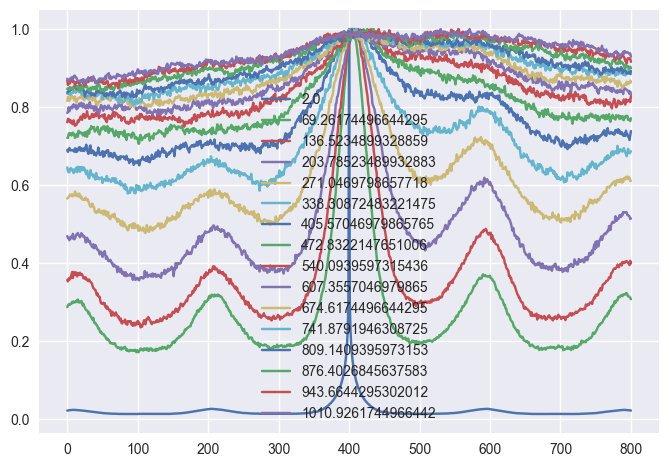

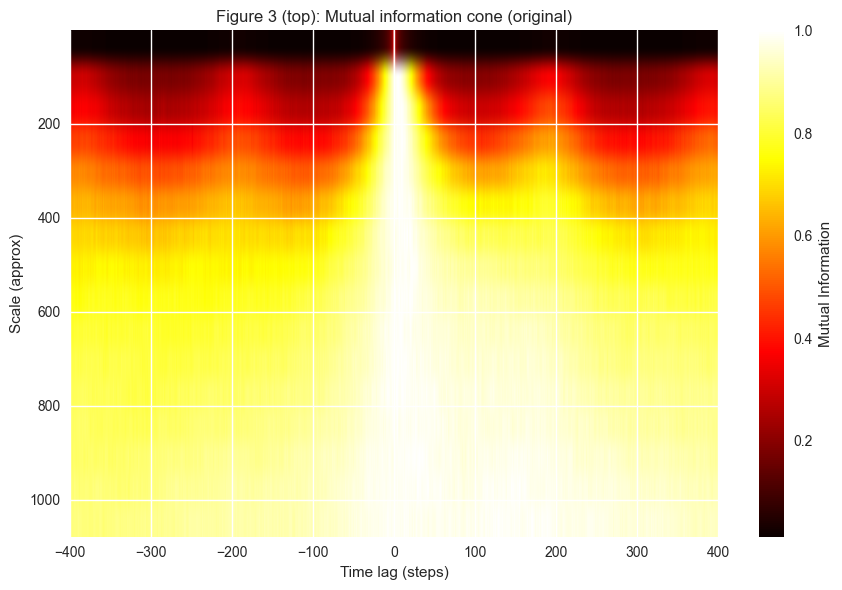

In [39]:
# I_map_without_gaps = []
# for row in I_map:
#     I_map_without_gaps.append(row[row>0])

# plt.figure(figsize=(9, 6))
# extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
# plt.imshow(I_map_without_gaps, aspect='auto', origin='upper', cmap='hot', extent=extent)
# plt.colorbar(label='Mutual Information')
# plt.xlabel('Time lag (steps)')
# plt.ylabel('Scale (approx)')
# plt.title('Figure 3 (top): Mutual information cone (original)')
# plt.tight_layout()
# plt.show()


I_normalized = []
for i,I in enumerate(I_map):
    if i <= max_scale_idx:
        I_normalized.append(I/np.max(I))
        plt.plot(I_normalized[i],label=scales[i])
    else:
        break
plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
# extent = [-max_time_lag, max_time_lag, scales[max_scale_idx], scales[0]]
plt.imshow(I_normalized, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

In [ ]:
# np.save("I_map_sandp_haar_scales_16_05.npy",scales)
# np.save("I_map_sandp_haar_16_05.npy", I_map)
# np.save("I_map_sandp_haar_normalized_16_05.npy", I_normalized)


In [36]:
I_map=np.load("I_map_sandp_haar_16_05.npy")
I_normalized=np.load("I_map_sandp_haar_normalized_16_05.npy")
max_time_lag = 200
ref_idx = 0  # smallest scale as reference
max_scale_idx=16
w_a_centered_list = [log_vol - np.mean(log_vol) for log_vol in log_vol_series]
w_ref = w_a_centered_list[ref_idx]
extent = [-max_time_lag, max_time_lag, scales[max_scale_idx], scales[0]]


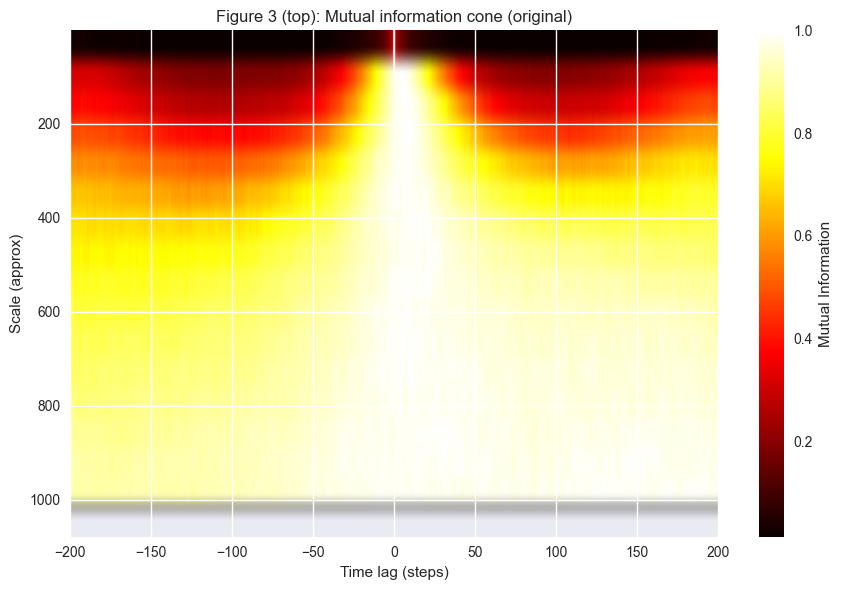

In [37]:

plt.figure(figsize=(9, 6))
# extent = [-max_time_lag, max_time_lag, scales[max_scale_idx], scales[0]]
plt.imshow(I_normalized, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

In [29]:
I_map=np.load("I_map_sandp_haar_16_05.npy")

I_map[15]

array([0.21631408, 0.21614924, 0.21516127, 0.21557947, 0.21398103,
       0.21586652, 0.21553407, 0.21402859, 0.21486444, 0.21505296,
       0.21568426, 0.21556486, 0.21421412, 0.21498391, 0.21446765,
       0.21358116, 0.21348973, 0.21366655, 0.2145934 , 0.21557892,
       0.21470601, 0.21356201, 0.215918  , 0.21514257, 0.21493726,
       0.21446885, 0.21491837, 0.21467816, 0.21319626, 0.21264253,
       0.21486438, 0.21543089, 0.21550132, 0.21641662, 0.21716943,
       0.21471496, 0.21464961, 0.21580772, 0.21508008, 0.21464778,
       0.21829202, 0.21639614, 0.21530441, 0.21638033, 0.21708578,
       0.21734972, 0.21650527, 0.21579148, 0.21735759, 0.21500321,
       0.21471511, 0.21557529, 0.21637962, 0.21516363, 0.21510797,
       0.21504583, 0.21741617, 0.21665309, 0.21475091, 0.21446047,
       0.21752868, 0.21458605, 0.21497158, 0.21596733, 0.2161721 ,
       0.21430773, 0.21536753, 0.21505191, 0.21581638, 0.21516163,
       0.21648792, 0.21808915, 0.2177309 , 0.21905535, 0.21559

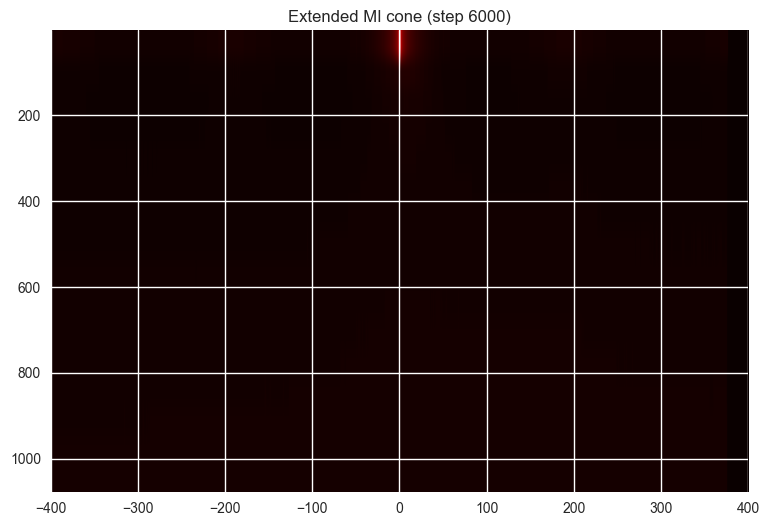

Progress: 6010/6400
Progress: 6020/6400
Progress: 6030/6400
Progress: 6040/6400
Progress: 6050/6400
Progress: 6060/6400
Progress: 6070/6400
Progress: 6080/6400
Progress: 6090/6400
Progress: 6100/6400
Progress: 6110/6400
Progress: 6120/6400
Progress: 6130/6400
Progress: 6140/6400
Progress: 6150/6400
Progress: 6160/6400
Progress: 6170/6400
Progress: 6180/6400
Progress: 6190/6400
Progress: 6200/6400
Progress: 6210/6400
Progress: 6220/6400
Progress: 6230/6400
Progress: 6240/6400
Progress: 6250/6400
Progress: 6260/6400
Progress: 6270/6400
Progress: 6280/6400
Progress: 6290/6400
Progress: 6300/6400
Progress: 6310/6400
Progress: 6320/6400
Progress: 6330/6400
Progress: 6340/6400
Progress: 6350/6400
Progress: 6360/6400
Progress: 6370/6400
Progress: 6380/6400
Progress: 6390/6400
Extension complete.


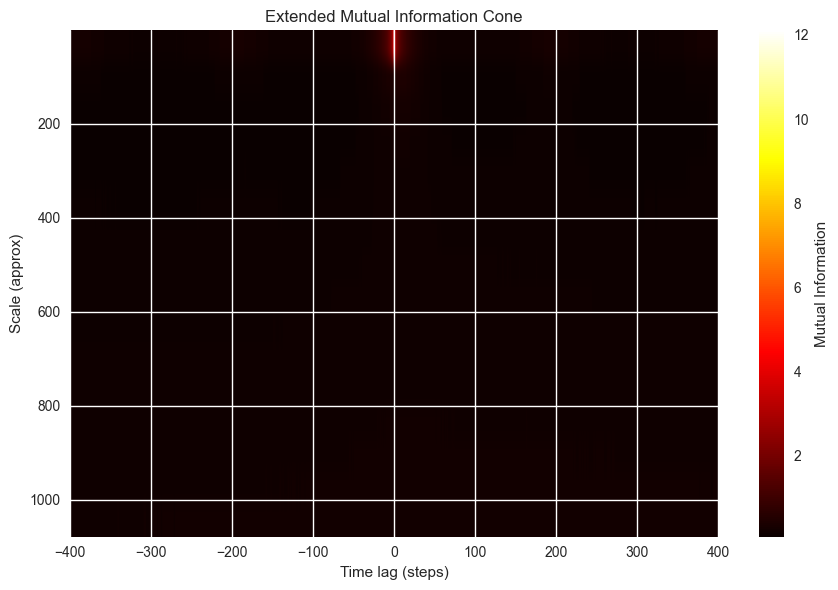

In [38]:
# ============================================
# Extend time-lag range and compute new values
# ============================================

import multiprocess as mp
from IPython.display import clear_output
# -----------------------------
# 1. Set new lag range
# -----------------------------
old_max_lag = max_time_lag          # e.g. 200
new_max_lag = 400                   # <-- change this to whatever you want

print(f"Extending lag range from ±{old_max_lag} to ±{new_max_lag}")

# -----------------------------
# 2. Create new I_map and copy old values
# -----------------------------
I_map_new = np.zeros((max_scale_idx, 2*new_max_lag + 1))

offset = new_max_lag - old_max_lag
I_map_new[:, offset:offset + (2*old_max_lag + 1)] = I_map[:16]

# -----------------------------
# 3. Build tasks ONLY for missing dt values
# -----------------------------
new_tasks = []

# negative dt beyond old range
for dt in range(-new_max_lag, -old_max_lag):
    for s_idx in range(max_scale_idx):
        new_tasks.append((s_idx, dt, w_a_centered_list, w_ref))

# positive dt beyond old range
for dt in range(old_max_lag+1, new_max_lag+1):
    for s_idx in range(max_scale_idx):
        new_tasks.append((s_idx, dt, w_a_centered_list, w_ref))

print(f"New tasks to compute: {len(new_tasks)}")

# -----------------------------
# 4. Compute missing MI values
# -----------------------------
with mp.Pool(mp.cpu_count()) as pool:
    for i, result in enumerate(pool.imap(compute_I, new_tasks)):
        s_idx, dt, _, _ = new_tasks[i]
        I_map_new[s_idx, dt + new_max_lag] = result

        # Progress
        if i % 10 == 0:
            print(f"Progress: {i}/{len(new_tasks)}")

        # Live update every 2000 steps
        if i % 1000 == 0 and i > 0:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(9, 6))
            ax.imshow(I_map_new, aspect='auto', origin='upper',
                      cmap='hot',
                      extent=[-new_max_lag, new_max_lag,
                              scales[max_scale_idx], scales[0]])
            ax.set_title(f"Extended MI cone (step {i})")
            plt.show()

# -----------------------------
# 5. Replace old map and lag
# -----------------------------
I_map = I_map_new
max_time_lag = new_max_lag
extent = [-max_time_lag, max_time_lag, scales[max_scale_idx], scales[0]]

print("Extension complete.")

# -----------------------------
# 6. Final plot
# -----------------------------
plt.figure(figsize=(9, 6))
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Extended Mutual Information Cone')
plt.tight_layout()
plt.show()


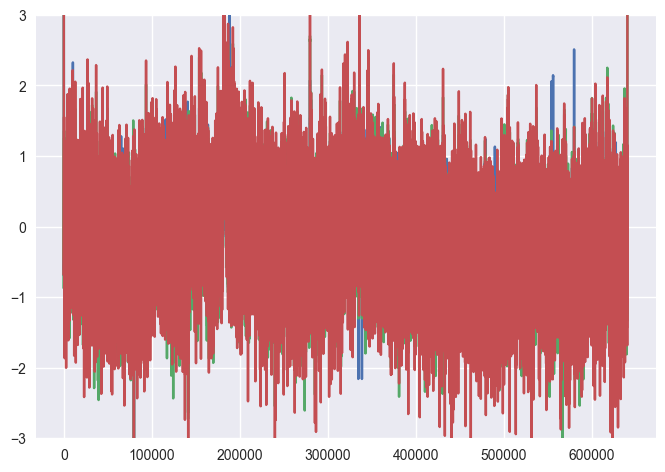

In [35]:
plt.plot(w_a_centered_list[0])
plt.plot(w_a_centered_list[1])
# plt.plot(w_a_centered_list[2])
plt.plot(w_a_centered_list[3])
# plt.plot(w_a_centered_list[4])
plt.ylim((-3,3))

plt.show()

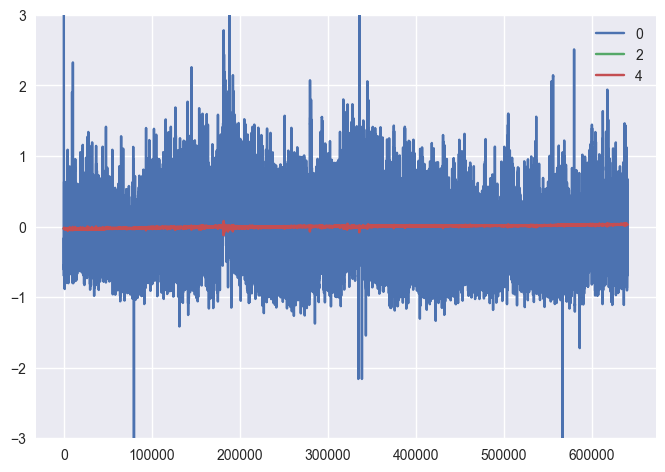

In [38]:
plt.plot(w_a_centered_list[0],label=0)
# plt.plot(w_a_centered_list[1])
plt.plot(w_a_centered_list[2][100:-100],label=2)
# plt.plot(w_a_centered_list[3])
plt.plot(w_a_centered_list[4][100:-100],label=4)
plt.ylim((-3,3))
plt.legend()
plt.show()

In [ ]:
I_map_slow = np.load("I_map_paper.npy")

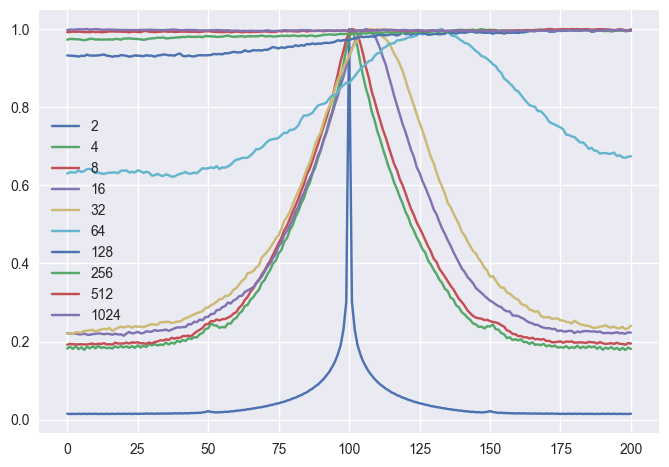

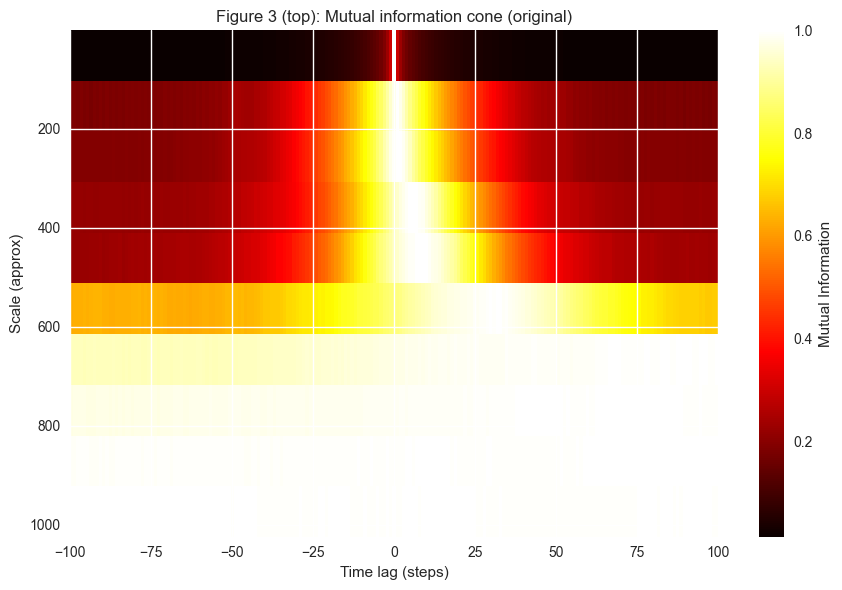

In [ ]:
I_normalized_slow = []
for i,I in enumerate(I_map_slow):
    I_normalized_slow.append(I/np.max(I))
    plt.plot(I_normalized_slow[i],label=scales[i])

plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
extent = [-100, 100, scales[-1], scales[0]]
plt.imshow(I_normalized_slow, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

### Shuffled control for Figure 3 (TODO)

We repeat the mutual information computation for the shuffled series, which should destroy the cascade structure and yield a noisy, structureless map.


In [ ]:
logP_shuffled2 = logP_shuffled  # from earlier
detail_series_sh2 = cwt_haar_fft(logP_shuffled, dt, scales)

# detail_series_sh2 = []
# for level in range(1, max_level+1):
#     cD = coeffs_sh2[-level]
#     up = upsample_to_length(cD, level, len(logP_shuffled2))
#     detail_series_sh2.append(up)
detail_series_sh2 = np.array(detail_series_sh2)

vol_series_sh2 = []
for s_idx in range(len(scales)):
    d = detail_series_sh2[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh2.append(vol)
vol_series_sh2 = np.array(vol_series_sh2)
log_vol_series_sh2 = np.log(vol_series_sh2 + 1e-12)

w_ref_sh = log_vol_series_sh2[ref_idx]
I_map_sh = np.zeros((len(scales), 2*max_time_lag+1))

for s_idx in range(len(scales)):
    w_other = log_vol_series_sh2[s_idx]
    for dt in range(-max_time_lag, max_time_lag+1):
        if dt >= 0:
            x = w_other[:-dt or None]
            y = w_ref_sh[dt:]
        else:
            x = w_other[-dt:]
            y = w_ref_sh[:dt or None]
        if len(x) < 10:
            I = 0
        else:
            I = gaussian_MI(x, y)
        I_map_sh[s_idx, dt + max_time_lag] = I

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map_sh, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (bottom): Mutual information cone (shuffled)')
plt.tight_layout()
plt.show()
